# Analyse de polysémie — 1000 mots français
Analyse à grande échelle : extraction automatique depuis Wikipedia, embeddings CamemBERT, scores de polysémie.

In [4]:
%run polybert_functions.ipynb

Loading weights: 100%|█████████████████████████████████████████████| 199/199 [00:00<00:00, 3715.95it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé : camembert-base


In [14]:
from wordfreq import top_n_list
mots_clean=[]
mots=top_n_list('fr',1000)
for mot in mots:
    if len(mot) >=5:
        mots_clean.append(mot)

print(f"{len(mots_clean)} mots sélectionnés")
print("Top 10 :", mots_clean[:10])
print("Nb de sens :", [len(wn.synsets(m, lang='fra')) for m in mots_clean[:10]])

671 mots sélectionnés
Top 10 : ['comme', 'cette', 'faire', 'était', 'aussi', 'quand', 'après', 'avoir', 'encore', 'alors']
Nb de sens : [7, 0, 101, 0, 6, 2, 5, 55, 20, 14]


In [15]:
# Extraction des phrases depuis Wikipedia 
corpus = build_corpus_auto(mots_clean, n_max=20)

mots_avec_corpus = [m for m, p in corpus.items() if len(p) >= 3]
#print(f"\n{len(mots_avec_corpus)} mots ont au moins 3 phrases extraites")

comme               : 98 phrases
cette               : 71 phrases
faire               : 96 phrases
était               : 149 phrases
aussi               : 67 phrases
quand               : 32 phrases
après               : 66 phrases
avoir               : 68 phrases
encore              : 44 phrases
alors               : 59 phrases
avait               : 122 phrases
entre               : 126 phrases
temps               : 157 phrases
autres              : 40 phrases
autre               : 71 phrases
france              : 200 phrases
monde               : 150 phrases
toujours            : 34 phrases
contre              : 131 phrases
votre               : 12 phrases
avant               : 102 phrases
depuis              : 80 phrases
notre               : 104 phrases
jamais              : 44 phrases
moins               : 55 phrases
leurs               : 88 phrases
toute               : 22 phrases
juste               : 107 phrases
vraiment            : 17 phrases
ainsi               : 111 phrases

In [18]:
corpus_filtre = {m: corpus[m] for m in mots_avec_corpus}
embeddings, phrases_retenues = extract_embeddings(corpus_filtre)

# Garder seulement les mots avec assez d'embeddings pour calculer un score fiable
embeddings = {m: v for m, v in embeddings.items() if len(v) >= 5}
print(f"\n{len(embeddings)} mots avec >= 5 embeddings")

comme               : 98 embeddings
cette               : 68 embeddings
faire               : 58 embeddings
était               : 149 embeddings
aussi               : 64 embeddings
quand               : 32 embeddings
après               : 57 embeddings
avoir               : 63 embeddings
encore              : 38 embeddings
alors               : 55 embeddings
avait               : 121 embeddings
entre               : 126 embeddings
temps               : 133 embeddings
autres              : 33 embeddings
autre               : 50 embeddings
france              : 155 embeddings
monde               : 127 embeddings
toujours            : 31 embeddings
contre              : 76 embeddings
votre               : 11 embeddings
avant               : 83 embeddings
depuis              : 79 embeddings
notre               : 32 embeddings
jamais              : 42 embeddings
moins               : 54 embeddings
leurs               : 88 embeddings
toute               : 22 embeddings
juste               : 

In [19]:
df_scores = compute_scores_df(embeddings)

print(f"{len(df_scores)} mots scorés")
print(df_scores.head(20).to_string(index=False))

666 mots scorés
     mot  score_polysemie  sim_moyenne  n_embeddings type
   quant         0.347262     0.571071            10    ?
   terme         0.329919     0.556069            71    ?
  appelé         0.320491     0.514084            27    ?
répondre         0.306198     0.510558            37    ?
   union         0.285696     0.543919           102    ?
   telle         0.285607     0.635662            12    ?
   bonne         0.285599     0.566915            31    ?
 seconde         0.284904     0.527099            84    ?
 partout         0.274517     0.578468            51    ?
  quelle         0.268507     0.504797            24    ?
  michel         0.267634     0.611902            91    ?
 changer         0.267031     0.663505            16    ?
   vient         0.263375     0.672937            23    ?
 faisant         0.262150     0.563141            15    ?
  europe         0.257501     0.607049           165    ?
   mêmes         0.257315     0.545352            10    

In [26]:
def get_nb_sens(mot:str)->int:
    return len(wn.synsets(mot))
        

In [27]:
def is_polysemantic(mot:str)->bool:
    return len(wn.synsets(mot))>=2            

In [28]:
df_scores['type']=df_scores.mot.apply(is_polysemantic)

In [29]:
df_scores['nb_sens']=df_scores.mot.apply(get_nb_sens)

In [36]:
df_scores.groupby('type')['score_polysemie'].mean()

type
False    0.147372
True     0.153257
Name: score_polysemie, dtype: float32

In [30]:
print("=== Top 20 mots les plus polysémiques ===")
print(df_scores.head(20)[["mot", "score_polysemie", "n_embeddings"]].to_string(index=False))

print("\n=== Top 20 mots les moins polysémiques ===")
print(df_scores.tail(20)[["mot", "score_polysemie", "n_embeddings"]].to_string(index=False))

=== Top 20 mots les plus polysémiques ===
     mot  score_polysemie  n_embeddings
   quant         0.347262            10
   terme         0.329919            71
  appelé         0.320491            27
répondre         0.306198            37
   union         0.285696           102
   telle         0.285607            12
   bonne         0.285599            31
 seconde         0.284904            84
 partout         0.274517            51
  quelle         0.268507            24
  michel         0.267634            91
 changer         0.267031            16
   vient         0.263375            23
 faisant         0.262150            15
  europe         0.257501           165
   mêmes         0.257315            10
  siècle         0.256526           101
  mesure         0.255092           111
  celles         0.255006            41
  moitié         0.251431            15

=== Top 20 mots les moins polysémiques ===
         mot  score_polysemie  n_embeddings
    utiliser         0.066093 

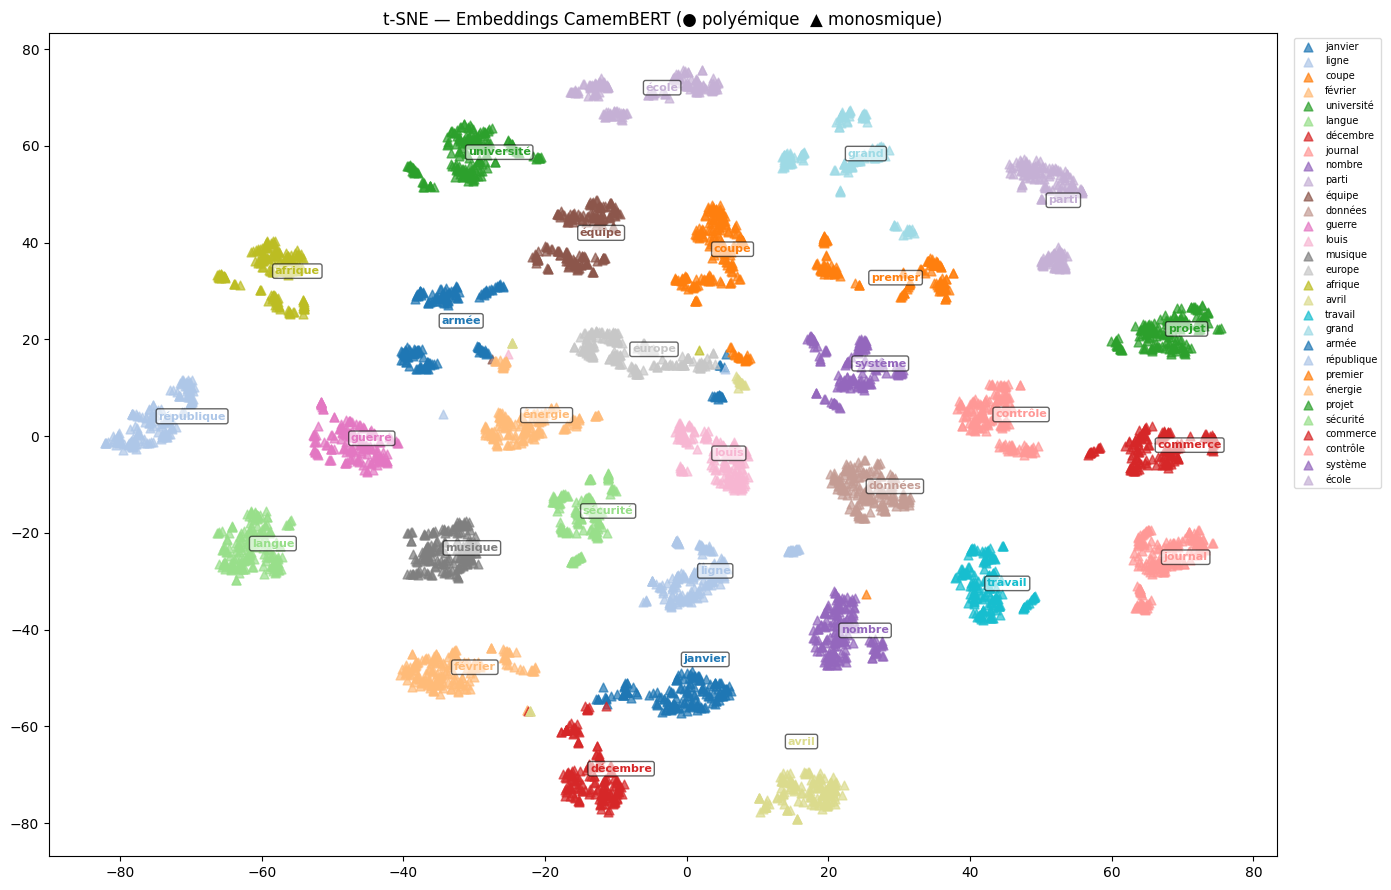

In [31]:
# t-SNE sur les 30 mots ayant le plus d'embeddings
top30_mots = df_scores.sort_values("n_embeddings", ascending=False).head(30)["mot"].tolist()
embeddings_top30 = {m: embeddings[m] for m in top30_mots if m in embeddings}

viz_tsne_global(embeddings_top30, fichier="tsne_1000mots.png")

Spearman ρ=0.061 (p=0.1723)  |  Pearson r=0.077 (p=0.0873)


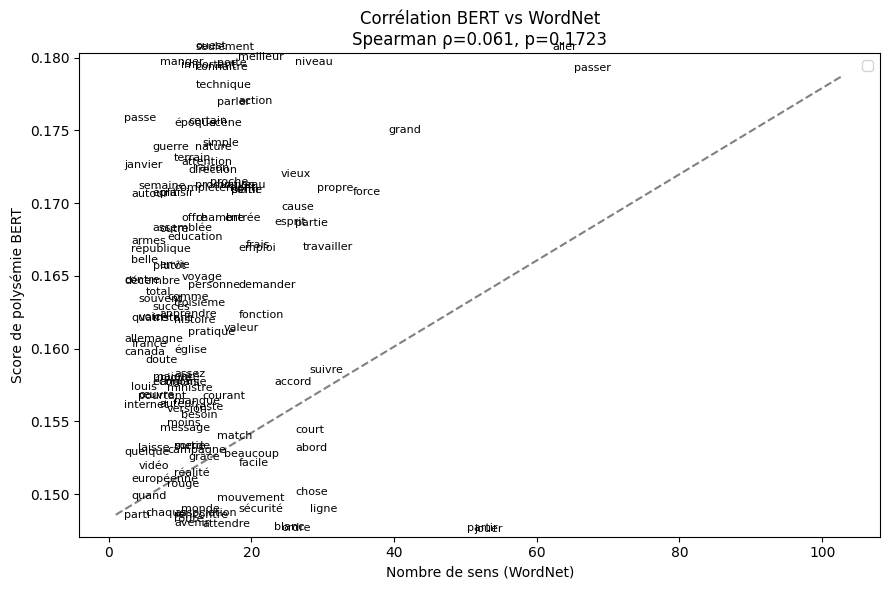

      mot  score_polysemie  nb_sens
    terme         0.329919       19
   appelé         0.320491        1
 répondre         0.306198       21
    union         0.285696       13
    bonne         0.285599        4
  seconde         0.284904       16
  partout         0.274517        2
   michel         0.267634        1
  changer         0.267031       26
   europe         0.257501        4
   siècle         0.256526        2
   mesure         0.255092       13
   moitié         0.251431        6
  endroit         0.250973       17
   autant         0.247010        1
    place         0.246365       33
    coeur         0.245244        2
    faire         0.245120      101
  lumière         0.244977       45
situation         0.243944        9
intérieur         0.243923       20
   hommes         0.242320        1
    façon         0.241142       12
  travers         0.239895        1
difficile         0.237933       13
   devoir         0.235670       28
    avril         0.233830  

In [32]:
df_corr = viz_correlation_wordnet(df_scores, fichier="correlation_wordnet_1000.png")
print(df_corr[["mot", "score_polysemie", "nb_sens"]].head(30).to_string(index=False))